# Sprint 5 - Business Value

Este notebook implementa PB-16: matriz costo-beneficio, busqueda de umbral, impacto economico y curva de ganancia para el modelo final del Sprint 4.

In [33]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation import (
    DEFAULT_BUSINESS_ASSUMPTIONS,
    evaluate_threshold,
    gain_curve,
    phishing_probability,
    threshold_search,
)


## 1. Cargar modelo final y test set

In [34]:
TARGET_COL = 'Result'
test_df = pd.read_csv('../data/processed/test.csv')
X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

model = joblib.load('../models/final_model.pkl')
y_proba_phishing = phishing_probability(model, X_test)

print(f'Test set: {X_test.shape}')
print(f'Distribucion: {dict(y_test.value_counts().sort_index())}')


Test set: (1170, 37)
Distribucion: {-1: np.int64(604), 1: np.int64(566)}


C:\Users\RyzFor\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 2. Matriz costo-beneficio

In [35]:
assumptions = DEFAULT_BUSINESS_ASSUMPTIONS.copy()
assumptions


{'benefit_tp': 100.0,
 'cost_fp': -20.0,
 'cost_fn': -80.0,
 'benefit_tn': 0.0,
 'annual_volume': 100000}

In [36]:
reference = evaluate_threshold(y_test, y_proba_phishing, threshold=0.50, assumptions=assumptions)
pd.DataFrame([reference])


,threshold,tn,fp,fn,tp,value_test,value_per_case,annual_value
0,0.5,537,29,30,574,54420.0,46.5128,4651282.05


## 3. Busqueda de umbral optimo

In [37]:
threshold_results, best = threshold_search(
    y_test,
    y_proba_phishing,
    assumptions=assumptions,
    start=0.05,
    stop=0.95,
    step=0.01,
)

threshold_results.to_csv('../reports/business_value_thresholds.csv', index=False)
pd.DataFrame([best])


,threshold,tn,fp,fn,tp,value_test,value_per_case,annual_value
0,0.09,476.0,90.0,3.0,601.0,58060.0,49.6239,4962393.16


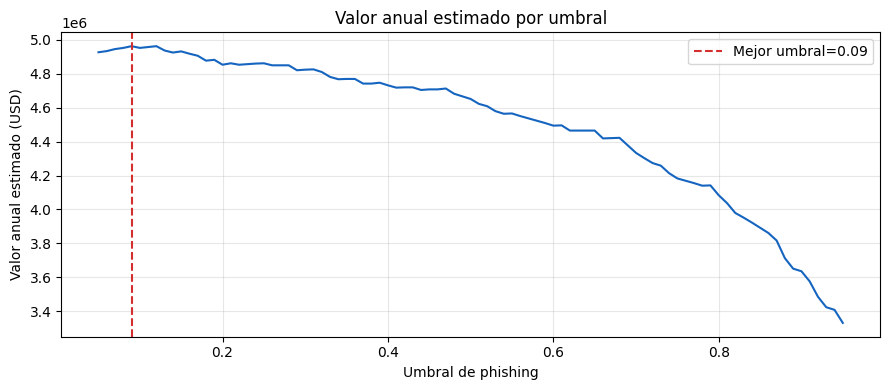

In [38]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(threshold_results['threshold'], threshold_results['annual_value'], color='#1565c0')
ax.axvline(best['threshold'], color='#d32f2f', linestyle='--', label=f"Mejor umbral={best['threshold']:.2f}")
ax.set_title('Valor anual estimado por umbral')
ax.set_xlabel('Umbral de phishing')
ax.set_ylabel('Valor anual estimado (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/business_value_thresholds.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Curva de ganancia y lift

In [39]:
gain = gain_curve(y_test, y_proba_phishing)
gain.to_csv('../reports/gain_curve.csv', index=False)
gain.head()


,contacted_share,captured_share,lift
0,0.000855,0.001656,1.937086
1,0.001709,0.003311,1.937086
2,0.002564,0.004967,1.937086
3,0.003419,0.006623,1.937086
4,0.004274,0.008278,1.937086


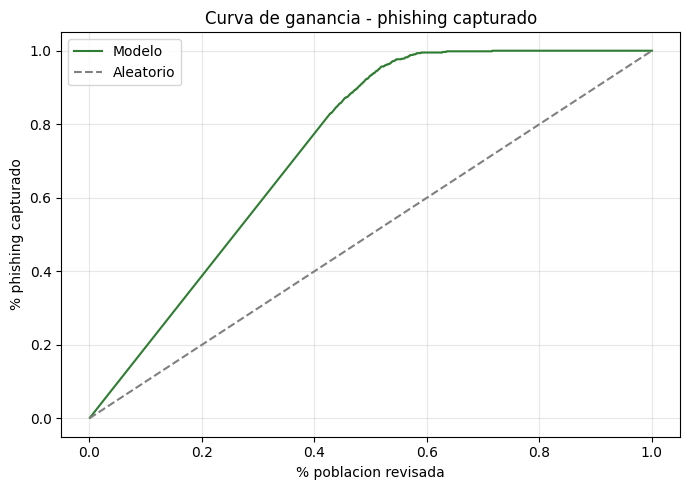

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gain['contacted_share'], gain['captured_share'], label='Modelo', color='#2e7d32')
ax.plot([0, 1], [0, 1], '--', label='Aleatorio', color='gray')
ax.set_title('Curva de ganancia - phishing capturado')
ax.set_xlabel('% poblacion revisada')
ax.set_ylabel('% phishing capturado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/gain_curve.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Interpretacion ejecutiva

In [41]:
summary = pd.DataFrame([
    {'item': 'umbral_referencia', 'value': reference['threshold']},
    {'item': 'valor_test_referencia_usd', 'value': reference['value_test']},
    {'item': 'valor_anual_referencia_usd', 'value': reference['annual_value']},
    {'item': 'umbral_optimo', 'value': best['threshold']},
    {'item': 'valor_anual_optimo_usd', 'value': best['annual_value']},
])
summary.to_csv('../reports/business_value_summary.csv', index=False)
summary


,item,value
0,umbral_referencia,0.50
1,valor_test_referencia_usd,54420.00
2,valor_anual_referencia_usd,4651282.05
3,umbral_optimo,0.09
4,valor_anual_optimo_usd,4962393.16
